<a href="https://colab.research.google.com/github/marioguerrerosalah/APRENDIZAJE--SUPERVISADO/blob/main/Proyecto_Final_SUpervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.1 BASE DE DATOS SELECCIONADA**

La base de datos seleccionada corresponde a los reportes de delitos de violencia intrafamiliar en Colombia desde el año 2010 hasta el 2021. Esta información contiene registros asociados a variables demográficas, geográficas y contextuales de los casos reportados, tales como:

* **Departamentos:** Son divisiones políticas y administrativas que conforman el territorio nacional.
* **Municipios:** Corresponden al segundo nivel de división administrativa en Colombia.
* **Código DANE:** Es una nomenclatura estandarizada, diseñada por el DANE, para la identificación de entidades territoriales (departamentos, distritos y municipios), áreas no municipalizadas y centros poblados, mediante la asignación de un código numérico único a cada una de estas unidades territoriales.
* **Medio del arma:** Se refiere al tipo de elemento utilizado para cometer el acto de violencia.
* **Fecha del hecho:** Describe el día en que ocurrió el evento violento.
* **Género:** Sexo de la víctima.
* **Grupo Etario:** Corresponde a la clasificación de las víctimas según su rango de edad.
* **Cantidad:** Número de personas que han resultado lesionadas


# **1.2 CASO DE NEGOCIO**


La violencia intrafamiliar representa una problemática crítica para las entidades gubernamentales, organismos de seguridad y organizaciones encargadas de la protección social en Colombia. Este fenómeno genera impactos negativos en la salud pública, la seguridad ciudadana y el bienestar de las familias.

Actualmente, las instituciones cuentan con grandes volúmenes de información histórica sobre casos reportados; sin embargo, gran parte de estos datos son utilizados únicamente para análisis descriptivos y reportes estadísticos, desaprovechando su potencial para generar modelos predictivos que apoyen la toma de decisiones.




# **1.3 PROBLEMA A RESOLVER**

Las entidades encargadas de gestionar y prevenir la violencia intrafamiliar enfrentan dificultades para identificar patrones asociados a los medios utilizados en los casos reportados.

El problema principal consiste en determinar qué características demográficas y contextuales influyen en el tipo de medio utilizado en los hechos de violencia intrafamiliar en Colombia.

Para abordar esta problemática, se propone desarrollar un modelo de aprendizaje supervisado capaz de clasificar el tipo de medio utilizado en los casos reportados a partir de variables como:

* Grupo etario.
* Género.
* Departamento.
* Municipio.
* Fecha del hecho.
* Cantidad de personas lesionadas.
* Información contextual del caso.

**Variable objetivo propuesta:** Armas Medios

**Modelo propuesto:** Clasificación

**Pregunta de negocio:** ¿Qué características demográficas y geográficas influyen en el tipo de medio utilizado en los casos de violencia intrafamiliar en Colombia?

# **2. Análisis Exploratorio y Preprocesamiento**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import time
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Linea de enfasis/Aprendizaje Supervisado Pronóstico/Proyecto Final/Reporte delito violencia intrafamiliar.csv')
df.head()
df.info()
df.shape
df.describe()

/tmp/ipykernel_1387/1332740734.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Linea de enfasis/Aprendizaje Supervisado Pronóstico/Proyecto Final/Reporte delito violencia intrafamiliar.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476970 entries, 0 to 476969
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DEPARTAMENTO  476970 non-null  object
 1   MUNICIPIO     476970 non-null  object
 2   CODIGO DANE   476970 non-null  object
 3   ARMAS MEDIOS  476968 non-null  object
 4   FECHA HECHO   476970 non-null  object
 5   GENERO        476967 non-null  object
 6   GRUPO ETARIO  475355 non-null  object
 7   CANTIDAD      476970 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 29.1+ MB


,CANTIDAD
count,476970.000000
mean,1.707764
std,3.338647
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,130.000000


**2.1 Identificación de tipos de variables**

In [ ]:
#Identificación de tipos de variables

# Variables numéricas
variables_numericas = df.select_dtypes(include=['int64', 'float64']).columns

# Variables categóricas
variables_categoricas = df.select_dtypes(include=['object']).columns

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
Index(['CANTIDAD'], dtype='object')

Variables categóricas:
Index(['DEPARTAMENTO', 'MUNICIPIO', 'CODIGO DANE', 'ARMAS MEDIOS',
       'FECHA HECHO', 'GENERO', 'GRUPO ETARIO'],
      dtype='object')


**2.2 Tratamiento de nulos o faltantes**

In [ ]:
#Valores faltantes y nulos

df.isnull().sum()

,0
DEPARTAMENTO,0
MUNICIPIO,0
CODIGO DANE,0
ARMAS MEDIOS,2
FECHA HECHO,0
GENERO,3
GRUPO ETARIO,1615
CANTIDAD,0


In [ ]:
#Tratamiento de nulos

# Variables categóricas
for col in variables_categoricas:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Variables numéricas
for col in variables_numericas:
    df[col].fillna(df[col].median(), inplace=True)

df.isnull().sum()

/tmp/ipykernel_1387/1245525824.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_1387/1245525824.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

,0
DEPARTAMENTO,0
MUNICIPIO,0
CODIGO DANE,0
ARMAS MEDIOS,0
FECHA HECHO,0
GENERO,0
GRUPO ETARIO,0
CANTIDAD,0


**2.3 Eliminacion de variables no relevantes**

In [ ]:
#Eliminacion de variables no relevantes
df_cleaned = df.drop(columns=['CODIGO DANE', 'MUNICIPIO']).copy()

# Mostrar las primeras filas del nuevo dataframe para verificar
print(df_cleaned.head())

# Verificar las columnas del nuevo dataframe
print(df_cleaned.columns)
df_cleaned.head()

   DEPARTAMENTO                 ARMAS MEDIOS FECHA HECHO     GENERO  \
0     ATLÁNTICO  ARMA BLANCA / CORTOPUNZANTE   1/01/2010  MASCULINO   
1        BOYACÁ  ARMA BLANCA / CORTOPUNZANTE   1/01/2010   FEMENINO   
2       CAQUETÁ  ARMA BLANCA / CORTOPUNZANTE   1/01/2010  MASCULINO   
3      CASANARE  ARMA BLANCA / CORTOPUNZANTE   1/01/2010   FEMENINO   
4  CUNDINAMARCA  ARMA BLANCA / CORTOPUNZANTE   1/01/2010   FEMENINO   

  GRUPO ETARIO  CANTIDAD  
0      ADULTOS         1  
1      ADULTOS         1  
2      ADULTOS         1  
3      ADULTOS         1  
4      ADULTOS         1  
Index(['DEPARTAMENTO', 'ARMAS MEDIOS', 'FECHA HECHO', 'GENERO', 'GRUPO ETARIO',
       'CANTIDAD'],
      dtype='object')


,DEPARTAMENTO,ARMAS MEDIOS,FECHA HECHO,GENERO,GRUPO ETARIO,CANTIDAD
0,ATLÁNTICO,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,MASCULINO,ADULTOS,1
1,BOYACÁ,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,FEMENINO,ADULTOS,1
2,CAQUETÁ,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,MASCULINO,ADULTOS,1
3,CASANARE,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,FEMENINO,ADULTOS,1
4,CUNDINAMARCA,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,FEMENINO,ADULTOS,1


Se eliminaron variables como CODIGO DANE y MUNICIPIO debido a que presentan alta cardinalidad o bajo aporte predictivo directo, además de generar redundancia con otras variables geográficas como DEPARTAMENTO.

**2.4 Analisis de variable objetivo**

In [ ]:
df_cleaned['ARMAS MEDIOS'].value_counts()

,count
ARMAS MEDIOS,
CONTUNDENTES,244947
SIN EMPLEO DE ARMAS,108785
NO REPORTADO,71921
ARMA BLANCA / CORTOPUNZANTE,38070
NO REPORTA,4421
ESCOPOLAMINA,3863
ARMA DE FUEGO,2323
CORTOPUNZANTES,1167
CORTANTES,1138


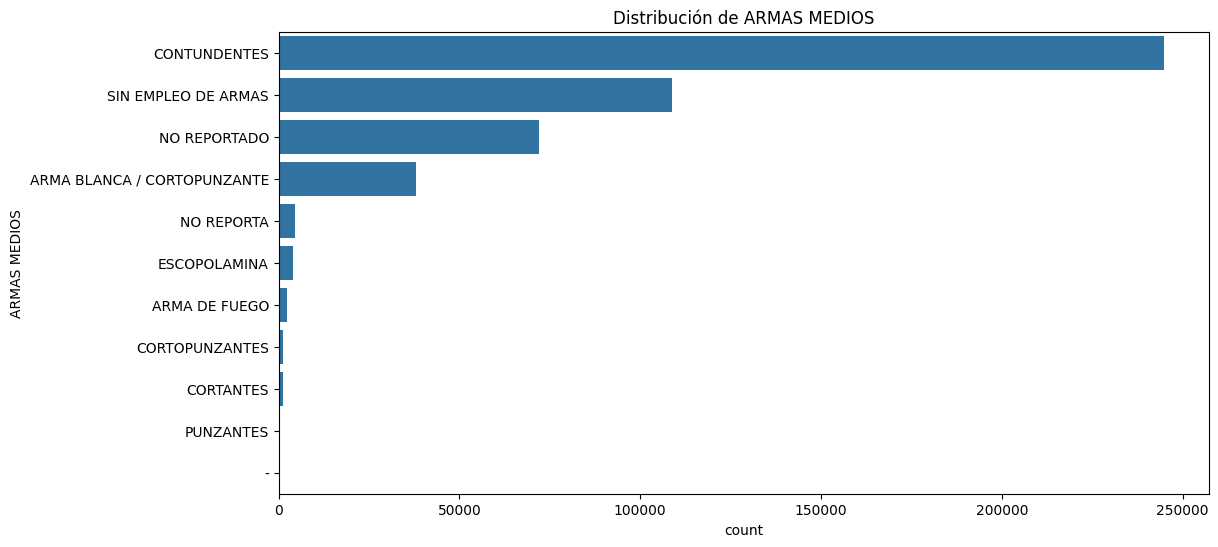

In [ ]:
# @title
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='ARMAS MEDIOS',
    order=df['ARMAS MEDIOS'].value_counts().index
)

plt.title('Distribución de ARMAS MEDIOS')
plt.show()

**ANALISIS VARIABLE OBJETIVO**

La variable objetivo ARMAS MEDIOS presenta un desbalance significativo entre categorías. Los medios “CONTUNDENTES” y “SIN EMPLEO DE ARMAS” concentran la mayor cantidad de registros, mientras que categorías como “PUNZANTES”, “CORTANTES” y “ESCOPOLAMINA” presentan una frecuencia considerablemente menor.

Adicionalmente, se identificaron categorías inconsistentes o redundantes relacionadas con armas cortopunzantes, así como registros poco informativos como “NO REPORTADO” y “-”. Por esta razón, fue necesario realizar un proceso de depuración y agrupación de categorías para mejorar la calidad del análisis y el desempeño del modelo de clasificación.

**2.5 Limpiar categorías problemáticas de ARMAS MEDIOS**

In [ ]:
# Eliminar categorías poco informativas
df_cleaned = df_cleaned[
    ~df_cleaned['ARMAS MEDIOS'].isin([
        'NO REPORTADO',
        'NO REPORTA',
        '-'
    ])
]

# Agrupar categorías similares
df_cleaned['ARMAS MEDIOS'] = df_cleaned['ARMAS MEDIOS'].replace({
    'CORTOPUNZANTES': 'ARMA BLANCA / CORTOPUNZANTE',
    'CORTANTES': 'ARMA BLANCA / CORTOPUNZANTE',
    'PUNZANTES': 'ARMA BLANCA / CORTOPUNZANTE'
})

# Verificar cambios
df_cleaned['ARMAS MEDIOS'].value_counts()

,count
ARMAS MEDIOS,
CONTUNDENTES,244947
SIN EMPLEO DE ARMAS,108785
ARMA BLANCA / CORTOPUNZANTE,40709
ESCOPOLAMINA,3863
ARMA DE FUEGO,2323


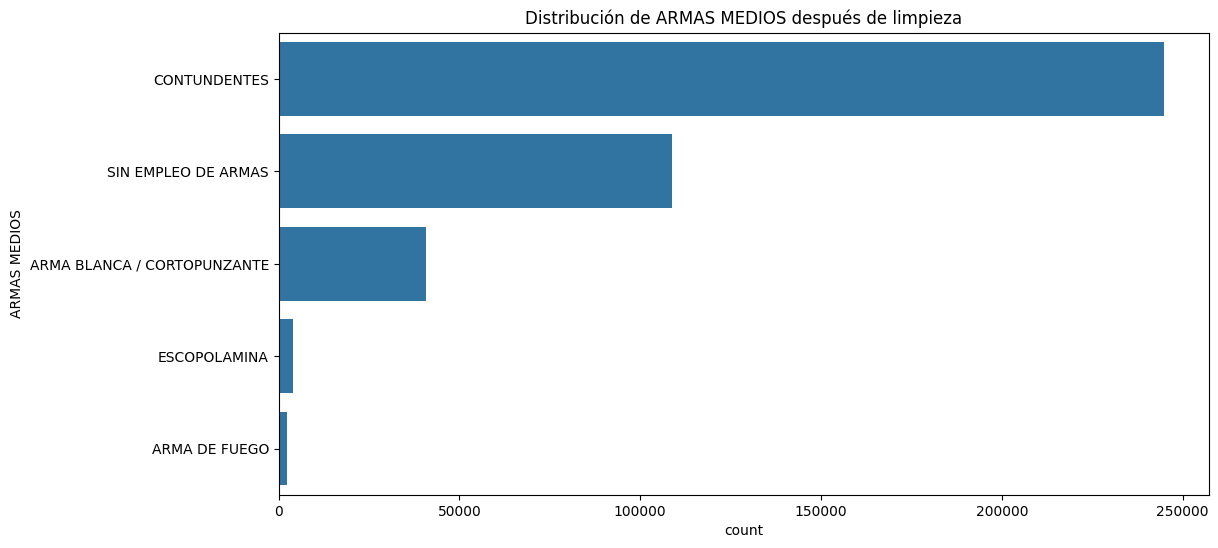

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_cleaned,
    y='ARMAS MEDIOS',
    order=df_cleaned['ARMAS MEDIOS'].value_counts().index
)

plt.title('Distribución de ARMAS MEDIOS después de limpieza')
plt.show()

**2.6 Convertimos la variable genero en binaria**

In [ ]:
df_cleaned.head()

,DEPARTAMENTO,ARMAS MEDIOS,FECHA HECHO,GENERO,GRUPO ETARIO,CANTIDAD
0,ATLÁNTICO,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,MASCULINO,ADULTOS,1
1,BOYACÁ,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,FEMENINO,ADULTOS,1
2,CAQUETÁ,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,MASCULINO,ADULTOS,1
3,CASANARE,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,FEMENINO,ADULTOS,1
4,CUNDINAMARCA,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,FEMENINO,ADULTOS,1


In [ ]:
df_cleaned['GENERO'] = df_cleaned['GENERO'].replace({
    'MASCULINO': 0,
    'FEMENINO': 1
})

# Verificar los cambios
print(df_cleaned['GENERO'].value_counts())
print(df_cleaned.head())


GENERO
1             309876
0              90558
NO REPORTA       186
-                  7
Name: count, dtype: int64
   DEPARTAMENTO                 ARMAS MEDIOS FECHA HECHO GENERO GRUPO ETARIO  \
0     ATLÁNTICO  ARMA BLANCA / CORTOPUNZANTE   1/01/2010      0      ADULTOS   
1        BOYACÁ  ARMA BLANCA / CORTOPUNZANTE   1/01/2010      1      ADULTOS   
2       CAQUETÁ  ARMA BLANCA / CORTOPUNZANTE   1/01/2010      0      ADULTOS   
3      CASANARE  ARMA BLANCA / CORTOPUNZANTE   1/01/2010      1      ADULTOS   
4  CUNDINAMARCA  ARMA BLANCA / CORTOPUNZANTE   1/01/2010      1      ADULTOS   

   CANTIDAD  
0         1  
1         1  
2         1  
3         1  
4         1  


In [ ]:
df_cleaned = df_cleaned[~df_cleaned['GENERO'].isin(['NO REPORTA', '-'])]

# Verificar los cambios
print(df_cleaned['GENERO'].value_counts())
print(df_cleaned.head())

GENERO
1    309876
0     90558
Name: count, dtype: int64
   DEPARTAMENTO                 ARMAS MEDIOS FECHA HECHO GENERO GRUPO ETARIO  \
0     ATLÁNTICO  ARMA BLANCA / CORTOPUNZANTE   1/01/2010      0      ADULTOS   
1        BOYACÁ  ARMA BLANCA / CORTOPUNZANTE   1/01/2010      1      ADULTOS   
2       CAQUETÁ  ARMA BLANCA / CORTOPUNZANTE   1/01/2010      0      ADULTOS   
3      CASANARE  ARMA BLANCA / CORTOPUNZANTE   1/01/2010      1      ADULTOS   
4  CUNDINAMARCA  ARMA BLANCA / CORTOPUNZANTE   1/01/2010      1      ADULTOS   

   CANTIDAD  
0         1  
1         1  
2         1  
3         1  
4         1  


Se eliminaron los valores de "NO REPORTA" y "-"

In [ ]:
df_cleaned['FECHA HECHO'] = pd.to_datetime(df_cleaned['FECHA HECHO'], format='mixed', dayfirst=True, errors='coerce')

df_cleaned.dropna(subset=['FECHA HECHO'], inplace=True)

df_cleaned.head()

,DEPARTAMENTO,ARMAS MEDIOS,FECHA HECHO,GENERO,GRUPO ETARIO,CANTIDAD
0,ATLÁNTICO,ARMA BLANCA / CORTOPUNZANTE,2010-01-01,0,ADULTOS,1
1,BOYACÁ,ARMA BLANCA / CORTOPUNZANTE,2010-01-01,1,ADULTOS,1
2,CAQUETÁ,ARMA BLANCA / CORTOPUNZANTE,2010-01-01,0,ADULTOS,1
3,CASANARE,ARMA BLANCA / CORTOPUNZANTE,2010-01-01,1,ADULTOS,1
4,CUNDINAMARCA,ARMA BLANCA / CORTOPUNZANTE,2010-01-01,1,ADULTOS,1


**2.8 creacion de variable mes numero y nombre del mes**

In [ ]:
df_cleaned['MES'] = df_cleaned['FECHA HECHO'].dt.month.astype(float)
df_cleaned.head()
df_cleaned['MES'].value_counts()

,count
MES,
1.0,40068
2.0,39223
3.0,39022
5.0,38492
4.0,35380
8.0,31681
9.0,31447
7.0,30903
6.0,30732


**2.9 Creamos variable de dia de la semana**

In [ ]:
df_cleaned['DIA_SEMANA'] = df_cleaned['FECHA HECHO'].dt.day_name()
spanish_day_names = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}
df_cleaned['DIA_SEMANA'] = df_cleaned['DIA_SEMANA'].map(spanish_day_names)
df_cleaned.head()
df_cleaned['DIA_SEMANA'].value_counts()

,count
DIA_SEMANA,
Domingo,75086
Lunes,61656
Sábado,55197
Martes,54312
Miércoles,53293
Jueves,51351
Viernes,49531


**2.10 Creamos variable binaria para fin de semana**

In [ ]:
df_cleaned['FIN_DE_SEMANA'] = df_cleaned['FECHA HECHO'].dt.dayofweek >= 5

df_cleaned['FIN_DE_SEMANA'] = df_cleaned['FIN_DE_SEMANA'].astype(int)

df_cleaned.head()
df_cleaned['FIN_DE_SEMANA'].value_counts()

,count
FIN_DE_SEMANA,
0,270143
1,130283


**2.11 Creamos la variable AÑO**

In [ ]:
df_cleaned['AÑO'] = df_cleaned['FECHA HECHO'].dt.year.astype(float)
df_cleaned.head()

,DEPARTAMENTO,ARMAS MEDIOS,FECHA HECHO,GENERO,GRUPO ETARIO,CANTIDAD,MES,DIA_SEMANA,FIN_DE_SEMANA,AÑO,FRECUENCIA_DEPTO
0,ATLÁNTICO,ARMA BLANCA / CORTOPUNZANTE,2010-01-01,0,ADULTOS,1,1.0,Viernes,0,2010.0,14727
1,BOYACÁ,ARMA BLANCA / CORTOPUNZANTE,2010-01-01,1,ADULTOS,1,1.0,Viernes,0,2010.0,26362
2,CAQUETÁ,ARMA BLANCA / CORTOPUNZANTE,2010-01-01,0,ADULTOS,1,1.0,Viernes,0,2010.0,4681
3,CASANARE,ARMA BLANCA / CORTOPUNZANTE,2010-01-01,1,ADULTOS,1,1.0,Viernes,0,2010.0,6093
4,CUNDINAMARCA,ARMA BLANCA / CORTOPUNZANTE,2010-01-01,1,ADULTOS,1,1.0,Viernes,0,2010.0,48673


**2.12 Creamos la variable Frecuencia por departamento**

In [ ]:
frecuencia_departamento = df_cleaned['DEPARTAMENTO'].value_counts()

df_cleaned['FRECUENCIA_DEPTO'] = df_cleaned['DEPARTAMENTO'].map(
    frecuencia_departamento
)
df_cleaned.head(5)

,DEPARTAMENTO,ARMAS MEDIOS,FECHA HECHO,GENERO,GRUPO ETARIO,CANTIDAD,MES,DIA_SEMANA,FIN_DE_SEMANA,AÑO,FRECUENCIA_DEPTO
0,ATLÁNTICO,ARMA BLANCA / CORTOPUNZANTE,2010-01-01,0,ADULTOS,1,1.0,Viernes,0,2010.0,14727
1,BOYACÁ,ARMA BLANCA / CORTOPUNZANTE,2010-01-01,1,ADULTOS,1,1.0,Viernes,0,2010.0,26362
2,CAQUETÁ,ARMA BLANCA / CORTOPUNZANTE,2010-01-01,0,ADULTOS,1,1.0,Viernes,0,2010.0,4681
3,CASANARE,ARMA BLANCA / CORTOPUNZANTE,2010-01-01,1,ADULTOS,1,1.0,Viernes,0,2010.0,6093
4,CUNDINAMARCA,ARMA BLANCA / CORTOPUNZANTE,2010-01-01,1,ADULTOS,1,1.0,Viernes,0,2010.0,48673


**2.13 Eliminacion de la variable fecha hecho**

In [ ]:
df_cleaned2 = df_cleaned.drop(columns=['FECHA HECHO'])

df_cleaned2.dropna(subset=['MES', 'AÑO'], inplace=True)

df_cleaned2.head()

,DEPARTAMENTO,ARMAS MEDIOS,GENERO,GRUPO ETARIO,CANTIDAD,MES,DIA_SEMANA,FIN_DE_SEMANA,AÑO,FRECUENCIA_DEPTO
0,ATLÁNTICO,ARMA BLANCA / CORTOPUNZANTE,0,ADULTOS,1,1.0,Viernes,0,2010.0,14727
1,BOYACÁ,ARMA BLANCA / CORTOPUNZANTE,1,ADULTOS,1,1.0,Viernes,0,2010.0,26362
2,CAQUETÁ,ARMA BLANCA / CORTOPUNZANTE,0,ADULTOS,1,1.0,Viernes,0,2010.0,4681
3,CASANARE,ARMA BLANCA / CORTOPUNZANTE,1,ADULTOS,1,1.0,Viernes,0,2010.0,6093
4,CUNDINAMARCA,ARMA BLANCA / CORTOPUNZANTE,1,ADULTOS,1,1.0,Viernes,0,2010.0,48673


**2.14 Creamos las variables binarias con los resutados de grupo etario**

In [ ]:
df_cleaned2['GRUPO ETARIO'].value_counts()

,count
GRUPO ETARIO,
ADULTOS,356958
ADOLESCENTES,23628
MENORES,19840


In [ ]:
grupo_etario_dummies = pd.get_dummies(
    df_cleaned2['GRUPO ETARIO'],
    prefix='VICTIMA',
    dtype=int
)

grupo_etario_dummies.head()

,VICTIMA_ADOLESCENTES,VICTIMA_ADULTOS,VICTIMA_MENORES
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


In [ ]:
df_cleaned2 = pd.concat(
    [df_cleaned2, grupo_etario_dummies],
    axis=1
)

df_cleaned2.head()

,DEPARTAMENTO,ARMAS MEDIOS,GENERO,GRUPO ETARIO,CANTIDAD,MES,DIA_SEMANA,FIN_DE_SEMANA,AÑO,FRECUENCIA_DEPTO,VICTIMA_ADOLESCENTES,VICTIMA_ADULTOS,VICTIMA_MENORES
0,ATLÁNTICO,ARMA BLANCA / CORTOPUNZANTE,0,ADULTOS,1,1.0,Viernes,0,2010.0,14727,0,1,0
1,BOYACÁ,ARMA BLANCA / CORTOPUNZANTE,1,ADULTOS,1,1.0,Viernes,0,2010.0,26362,0,1,0
2,CAQUETÁ,ARMA BLANCA / CORTOPUNZANTE,0,ADULTOS,1,1.0,Viernes,0,2010.0,4681,0,1,0
3,CASANARE,ARMA BLANCA / CORTOPUNZANTE,1,ADULTOS,1,1.0,Viernes,0,2010.0,6093,0,1,0
4,CUNDINAMARCA,ARMA BLANCA / CORTOPUNZANTE,1,ADULTOS,1,1.0,Viernes,0,2010.0,48673,0,1,0


**2.15 cONVERTIREMOS DIA SEMANA A VARIABLE BINARIA**

In [ ]:
dias_dummies = pd.get_dummies(
    df_cleaned2['DIA_SEMANA'],
    prefix='DIA',
    dtype=int
)

df_cleaned2 = pd.concat(
    [df_cleaned2, dias_dummies],
    axis=1
)

df_cleaned2.drop(columns=['DIA_SEMANA'], inplace=True)
df_cleaned2.head()

,DEPARTAMENTO,ARMAS MEDIOS,GENERO,GRUPO ETARIO,CANTIDAD,MES,FIN_DE_SEMANA,AÑO,FRECUENCIA_DEPTO,VICTIMA_ADOLESCENTES,VICTIMA_ADULTOS,VICTIMA_MENORES,DIA_Domingo,DIA_Jueves,DIA_Lunes,DIA_Martes,DIA_Miércoles,DIA_Sábado,DIA_Viernes
0,ATLÁNTICO,ARMA BLANCA / CORTOPUNZANTE,0,ADULTOS,1,1.0,0,2010.0,14727,0,1,0,0,0,0,0,0,0,1
1,BOYACÁ,ARMA BLANCA / CORTOPUNZANTE,1,ADULTOS,1,1.0,0,2010.0,26362,0,1,0,0,0,0,0,0,0,1
2,CAQUETÁ,ARMA BLANCA / CORTOPUNZANTE,0,ADULTOS,1,1.0,0,2010.0,4681,0,1,0,0,0,0,0,0,0,1
3,CASANARE,ARMA BLANCA / CORTOPUNZANTE,1,ADULTOS,1,1.0,0,2010.0,6093,0,1,0,0,0,0,0,0,0,1
4,CUNDINAMARCA,ARMA BLANCA / CORTOPUNZANTE,1,ADULTOS,1,1.0,0,2010.0,48673,0,1,0,0,0,0,0,0,0,1


**2.16 DETECCION DE OUTLIERS**

In [ ]:
df_cleaned2[['CANTIDAD', 'MES', 'FRECUENCIA_DEPTO']].describe()

,CANTIDAD,MES,FRECUENCIA_DEPTO
count,400426.000000,400426.000000,400426.000000
mean,1.647455,6.048418,27725.843756
std,2.763290,3.430681,17552.540012
min,1.000000,1.000000,6.000000
25%,1.000000,3.000000,12760.000000
50%,1.000000,6.000000,26362.000000
75%,1.000000,9.000000,48673.000000
max,101.000000,12.000000,53276.000000


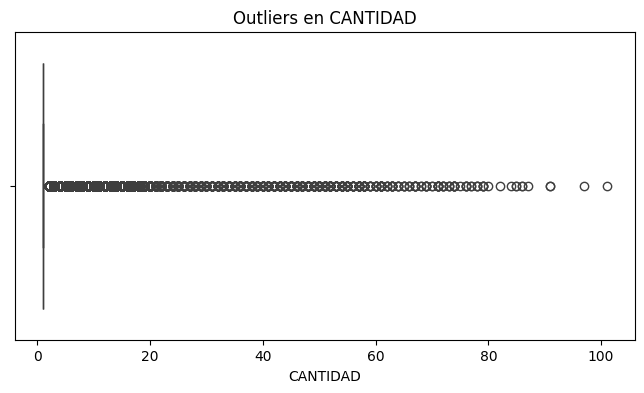

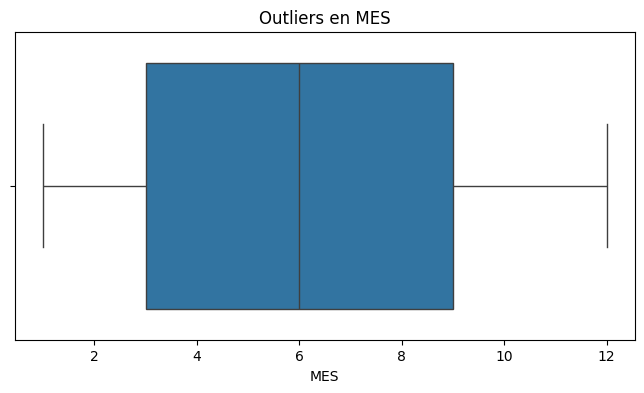

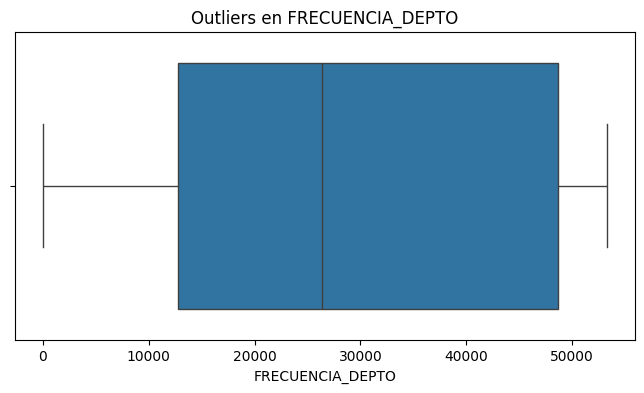

In [ ]:
variables_numericas = [
    'CANTIDAD',
    'MES',
    'FRECUENCIA_DEPTO'
]

for col in variables_numericas:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df_cleaned2[col])

    plt.title(f'Outliers en {col}')

    plt.show()

**2.17 Tratamiento de outliers**

In [ ]:
df_cleaned2 = df_cleaned2[
    df_cleaned2['CANTIDAD'] <= 10
]

Se identificaron valores extremos en la variable CANTIDAD mediante diagramas de caja. Con el fin de evitar distorsiones en el entrenamiento del modelo, se eliminaron registros con cantidades superiores a 10, ya que representaban casos atípicos poco frecuentes.

**2.18 Visualizaciones Exploratorias**

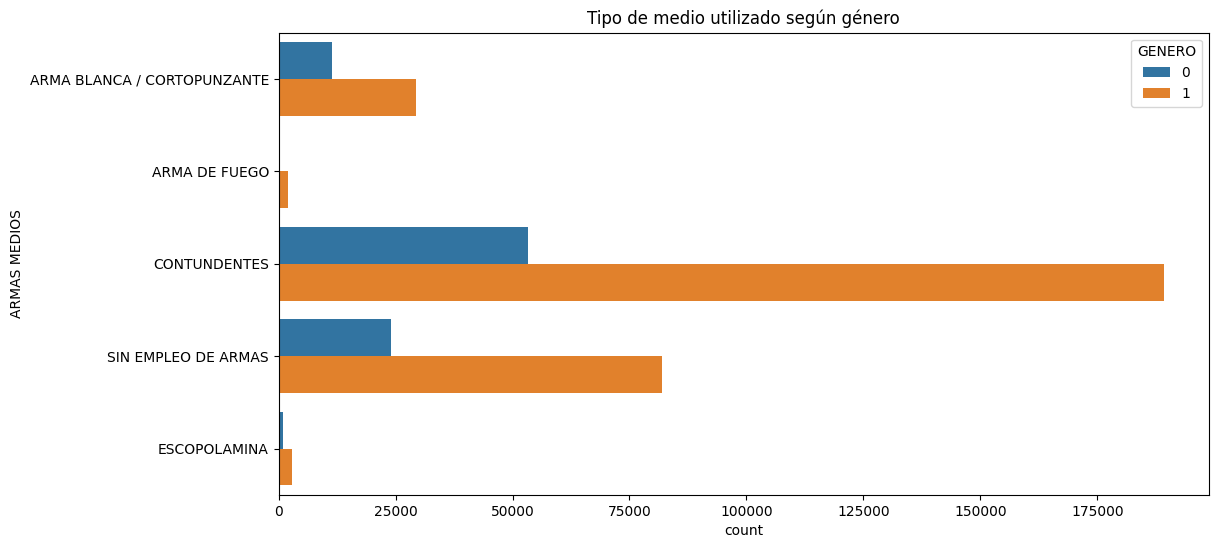

In [ ]:
# Género vs ARMAS MEDIOS

plt.figure(figsize=(12,6))

sns.countplot(
    data=df_cleaned2,
    y='ARMAS MEDIOS',
    hue='GENERO'
)

plt.title('Tipo de medio utilizado según género')

plt.show()

Los medios “CONTUNDENTES” y “SIN EMPLEO DE ARMAS” representan la mayor cantidad de casos de violencia intrafamiliar. Además, se observa una mayor frecuencia de registros en víctimas del género femenino, especialmente en los casos relacionados con medios contundentes.

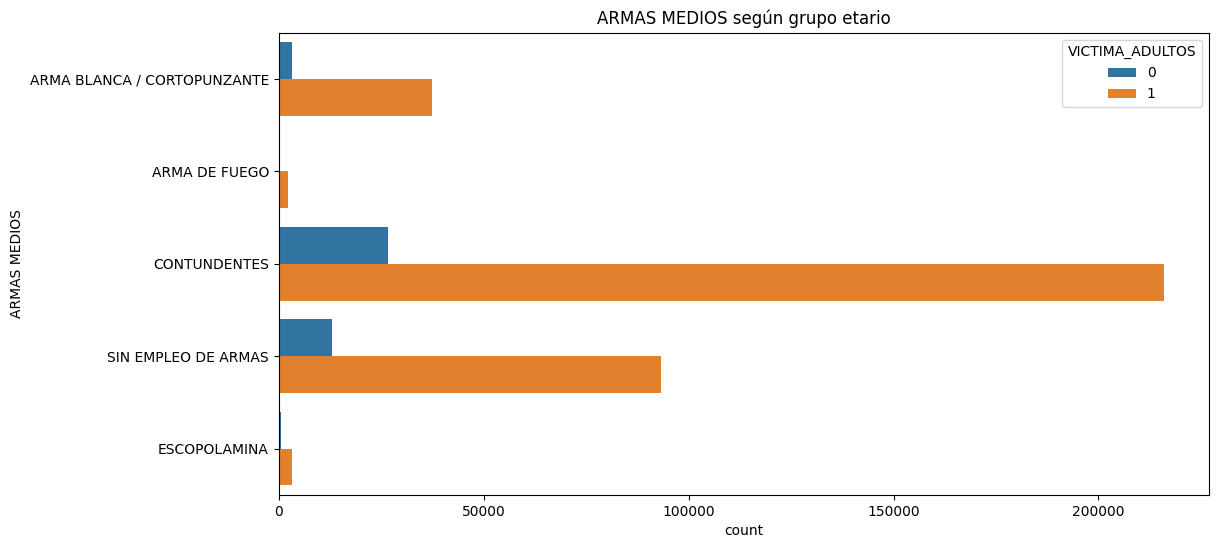

In [ ]:
#Grupo etario vs ARMAS MEDIOS

plt.figure(figsize=(12,6))

df_cleaned2_plot = df_cleaned2.loc[:, ~df_cleaned2.columns.duplicated()].copy()

sns.countplot(
    data=df_cleaned2_plot,
    y='ARMAS MEDIOS',
    hue='VICTIMA_ADULTOS'
)

plt.title('ARMAS MEDIOS según grupo etario')

plt.show()

La gráfica muestra que la mayor cantidad de casos de violencia intrafamiliar corresponde a víctimas adultas, especialmente en los medios “CONTUNDENTES” y “SIN EMPLEO DE ARMAS”. En contraste, los grupos no adultos presentan una menor frecuencia en todas las categorías analizadas.

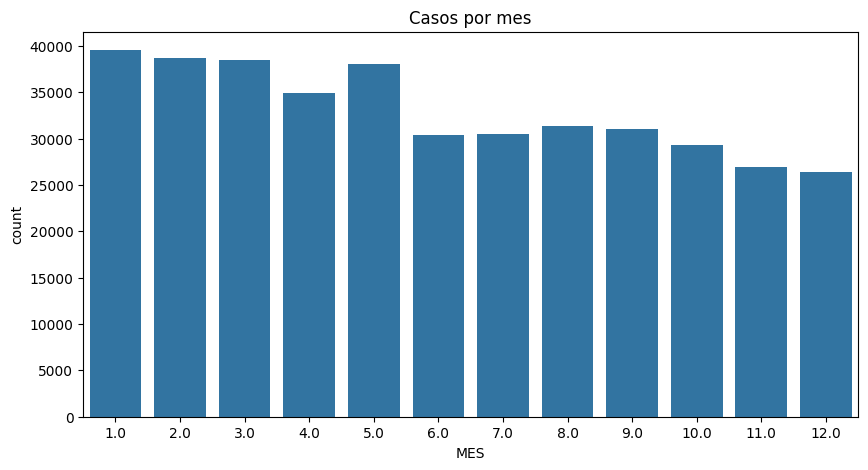

In [ ]:
#Casos por mes

plt.figure(figsize=(10,5))

sns.countplot(
    data=df_cleaned2,
    x='MES'
)

plt.title('Casos por mes')

plt.show()

La distribución de casos por mes muestra una mayor concentración de registros durante los primeros meses del año, especialmente entre enero y mayo. Posteriormente, se observa una disminución gradual en la cantidad de casos reportados hacia el final del año.

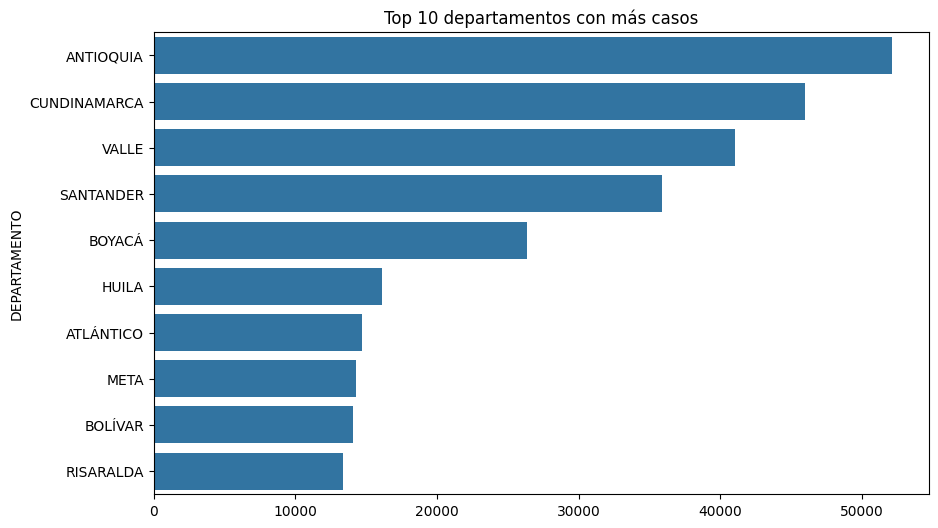

In [ ]:
#Top departamentos con mas casos

top_departamentos = df_cleaned2['DEPARTAMENTO'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_departamentos.values,
    y=top_departamentos.index
)

plt.title('Top 10 departamentos con más casos')

plt.show()

La gráfica muestra que Antioquia, Cundinamarca y Valle concentran la mayor cantidad de casos de violencia intrafamiliar registrados en el dataset. Esto evidencia una mayor frecuencia de reportes en determinados departamentos del país, lo que puede indicar zonas con mayor incidencia o mayor nivel de registro de los casos.

**2.19 Escalamiento de variables numericas**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

variables_numericas = [
    'CANTIDAD',
    'FRECUENCIA_DEPTO'
]

df_cleaned_scaled = df_cleaned2.copy()

df_cleaned_scaled[variables_numericas] = scaler.fit_transform(
    df_cleaned_scaled[variables_numericas]
)

df_cleaned_scaled.head()

,DEPARTAMENTO,ARMAS MEDIOS,GENERO,GRUPO ETARIO,CANTIDAD,MES,FIN_DE_SEMANA,AÑO,FRECUENCIA_DEPTO,VICTIMA_ADOLESCENTES,VICTIMA_ADULTOS,VICTIMA_MENORES,DIA_Domingo,DIA_Jueves,DIA_Lunes,DIA_Martes,DIA_Miércoles,DIA_Sábado,DIA_Viernes
0,ATLÁNTICO,ARMA BLANCA / CORTOPUNZANTE,0,ADULTOS,-0.369097,1.0,0,2010.0,-0.728842,0,1,0,0,0,0,0,0,0,1
1,BOYACÁ,ARMA BLANCA / CORTOPUNZANTE,1,ADULTOS,-0.369097,1.0,0,2010.0,-0.064111,0,1,0,0,0,0,0,0,0,1
2,CAQUETÁ,ARMA BLANCA / CORTOPUNZANTE,0,ADULTOS,-0.369097,1.0,0,2010.0,-1.302790,0,1,0,0,0,0,0,0,0,1
3,CASANARE,ARMA BLANCA / CORTOPUNZANTE,1,ADULTOS,-0.369097,1.0,0,2010.0,-1.222120,0,1,0,0,0,0,0,0,0,1
4,CUNDINAMARCA,ARMA BLANCA / CORTOPUNZANTE,1,ADULTOS,-0.369097,1.0,0,2010.0,1.210561,0,1,0,0,0,0,0,0,0,1


**2.20 Matriz de correlacion**

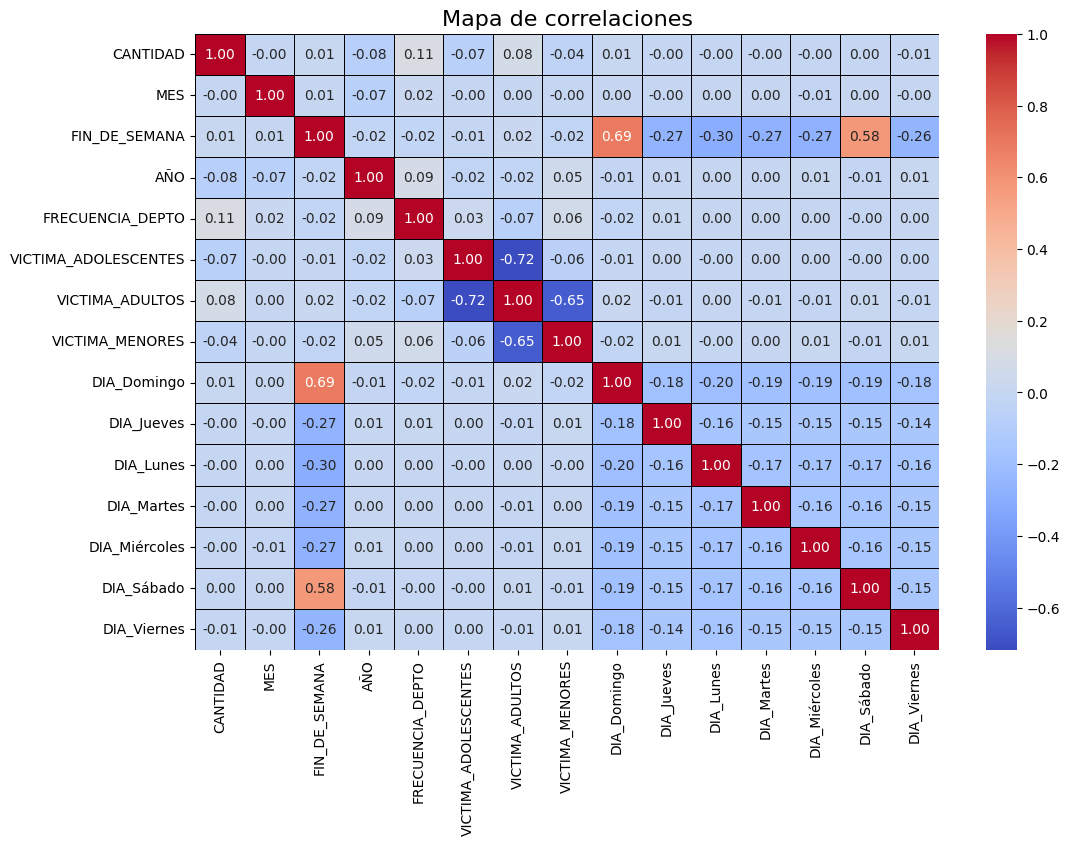

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df_cleaned2.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=.5,
    linecolor='black',
    annot_kws={"size": 10}
)

plt.title('Mapa de correlaciones', fontsize=16)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

In [ ]:
df_cleaned2.info()
df_cleaned2.head()
df_cleaned2.shape

<class 'pandas.core.frame.DataFrame'>
Index: 395662 entries, 0 to 476961
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   DEPARTAMENTO          395662 non-null  object 
 1   ARMAS MEDIOS          395662 non-null  object 
 2   GENERO                395662 non-null  object 
 3   GRUPO ETARIO          395662 non-null  object 
 4   CANTIDAD              395662 non-null  int64  
 5   MES                   395662 non-null  float64
 6   FIN_DE_SEMANA         395662 non-null  int64  
 7   AÑO                   395662 non-null  float64
 8   FRECUENCIA_DEPTO      395662 non-null  int64  
 9   VICTIMA_ADOLESCENTES  395662 non-null  int64  
 10  VICTIMA_ADULTOS       395662 non-null  int64  
 11  VICTIMA_MENORES       395662 non-null  int64  
 12  DIA_Domingo           395662 non-null  int64  
 13  DIA_Jueves            395662 non-null  int64  
 14  DIA_Lunes             395662 non-null  int64  
 15  DIA_M

(395662, 19)

# **2.21 Analisis del preprocesamiento y exploratorio**

El preprocesamiento permitió dejar la base en condiciones adecuadas para modelar. Se trataron valores faltantes, se depuró la variable objetivo `ARMAS MEDIOS`, se agruparon categorías similares y se crearon variables temporales como mes, año, día de la semana y fin de semana. También se transformó el grupo etario en variables binarias y se escaló la información numérica.

En el análisis exploratorio se observa que los registros están concentrados principalmente en víctimas de género femenino y en población adulta. Además, los medios más frecuentes son `CONTUNDENTES` y `SIN EMPLEO DE ARMAS`, lo que muestra un desbalance importante en la variable objetivo. Territorialmente, departamentos como Antioquia, Cundinamarca y Valle concentran una alta cantidad de reportes.

Este punto es importante para el modelo porque anticipa una dificultad: las clases minoritarias, como `ARMA DE FUEGO` y `ESCOPOLAMINA`, tienen muchos menos registros, por lo que pueden ser más difíciles de predecir correctamente.

# **3. Modelado Predictivo**

## 3.1 Preparación de Features y División Train/Test

Se utilizan las variables preprocesadas en el punto 2. La variable objetivo es **ARMAS MEDIOS** (clasificación multiclase con 5 categorías). Se aplica `LabelEncoder` para convertirla a enteros y `StandardScaler` para escalar los features numéricos.

In [ ]:
# Definición de features y variable objetivo
# Se incluyen las variables de día de la semana creadas previamente con get_dummies.

features_base = [
    'GENERO', 'CANTIDAD', 'MES', 'AÑO', 'FIN_DE_SEMANA',
    'FRECUENCIA_DEPTO',
    'VICTIMA_ADOLESCENTES', 'VICTIMA_ADULTOS', 'VICTIMA_MENORES'
]

dia_cols = [c for c in df_cleaned_scaled.columns if c.startswith('DIA_')]
feature_cols = [c for c in features_base + dia_cols if c in df_cleaned_scaled.columns]

X = df_cleaned_scaled[feature_cols].copy()
y_raw = df_cleaned_scaled['ARMAS MEDIOS'].copy()

# Codificar variable objetivo
le = LabelEncoder()
y = le.fit_transform(y_raw)

# División entrenamiento / prueba antes de imputar y escalar para evitar fuga de información
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Variables usadas en el modelo:")
print(feature_cols)
print(f"Conjunto de entrenamiento: {X_train_df.shape[0]:,} registros")
print(f"Conjunto de prueba:        {X_test_df.shape[0]:,} registros")

Variables usadas en el modelo:
['GENERO', 'CANTIDAD', 'MES', 'AÑO', 'FIN_DE_SEMANA', 'FRECUENCIA_DEPTO', 'VICTIMA_ADOLESCENTES', 'VICTIMA_ADULTOS', 'VICTIMA_MENORES', 'DIA_Domingo', 'DIA_Jueves', 'DIA_Lunes', 'DIA_Martes', 'DIA_Miércoles', 'DIA_Sábado', 'DIA_Viernes']
Conjunto de entrenamiento: 316,529 registros
Conjunto de prueba:        79,133 registros


In [ ]:
# Imputación y escalamiento ajustados solo con el conjunto de entrenamiento
imputer = SimpleImputer(strategy='mean')
X_train_imp = imputer.fit_transform(X_train_df)
X_test_imp = imputer.transform(X_test_df)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_imp)
X_test = scaler.transform(X_test_imp)

print(f"Conjunto de entrenamiento escalado: {X_train.shape}")
print(f"Conjunto de prueba escalado:        {X_test.shape}")
print(f"Proporción test: {X_test.shape[0]/(X_train.shape[0] + X_test.shape[0]):.0%}")

Conjunto de entrenamiento escalado: (316529, 16)
Conjunto de prueba escalado:        (79133, 16)
Proporción test: 20%


## 3.2 Definición e Implementación de Modelos

Se implementan **cuatro modelos** de clasificación supervisada:

1. **Regresión Logística** — modelo lineal de referencia (baseline)
2. **Árbol de Decisión** — modelo interpretable no lineal
3. **Random Forest** — ensamble de árboles con bagging
4. **Gradient Boosting** — ensamble secuencial con boosting



In [ ]:
# Definición de modelos con hiperparámetros ajustados
modelos = {
    'Regresión Logística': LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver='lbfgs',
        multi_class='auto',
        random_state=42
    ),
    'Árbol de Decisión': DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    ),
}

print("Modelos configurados:")
for nombre, modelo in modelos.items():
    print(f"  {nombre}")


Modelos configurados:
  Regresión Logística
  Árbol de Decisión
  Random Forest
  Gradient Boosting


In [ ]:
# Entrenamiento y evaluación de todos los modelos
resultados = {}
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    print(f"Entrenando: {nombre}...", end=' ')
    t0 = time.time()
    modelo.fit(X_train, y_train)
    tiempo = time.time() - t0

    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

    resultados[nombre] = {
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'F1-Macro': round(f1_macro, 4),
        'Balanced Accuracy': round(bal_acc, 4),
        'AUC-ROC': round(auc, 4),
        'Tiempo (s)': round(tiempo, 1)
    }
    modelos_entrenados[nombre] = modelo

    print(f"Accuracy={acc:.4f}  F1={f1:.4f}  Macro-F1={f1_macro:.4f}  AUC={auc:.4f}  [{tiempo:.1f}s]")

print("\nEntrenamiento completado.")

Entrenando: Regresión Logística... Accuracy=0.6157  F1=0.4927  Macro-F1=0.1723  AUC=0.6167  [10.2s]
Entrenando: Árbol de Decisión... Accuracy=0.6702  F1=0.6205  Macro-F1=0.2770  AUC=0.7578  [0.9s]
Entrenando: Random Forest... Accuracy=0.6626  F1=0.5954  Macro-F1=0.2480  AUC=0.7597  [27.6s]
Entrenando: Gradient Boosting... Accuracy=0.6736  F1=0.6255  Macro-F1=0.2787  AUC=0.7716  [280.6s]

Entrenamiento completado.


## 3.3 Tabla Comparativa de Resultados

In [ ]:
# Tabla comparativa de métricas
tabla_resultados = pd.DataFrame(resultados).T.sort_values('F1-Score', ascending=False)

print("=" * 65)
print("          TABLA COMPARATIVA DE MODELOS")
print("=" * 65)
print(tabla_resultados.to_string())
print("=" * 65)


          TABLA COMPARATIVA DE MODELOS
                     Accuracy  Precision  Recall  F1-Score  F1-Macro  Balanced Accuracy  AUC-ROC  Tiempo (s)
Gradient Boosting      0.6736     0.6473  0.6736    0.6255    0.2787             0.2777   0.7716       280.6
Árbol de Decisión      0.6702     0.6398  0.6702    0.6205    0.2770             0.2747   0.7578         0.9
Random Forest          0.6626     0.6407  0.6626    0.5954    0.2480             0.2548   0.7597        27.6
Regresión Logística    0.6157     0.5198  0.6157    0.4927    0.1723             0.2072   0.6167        10.2


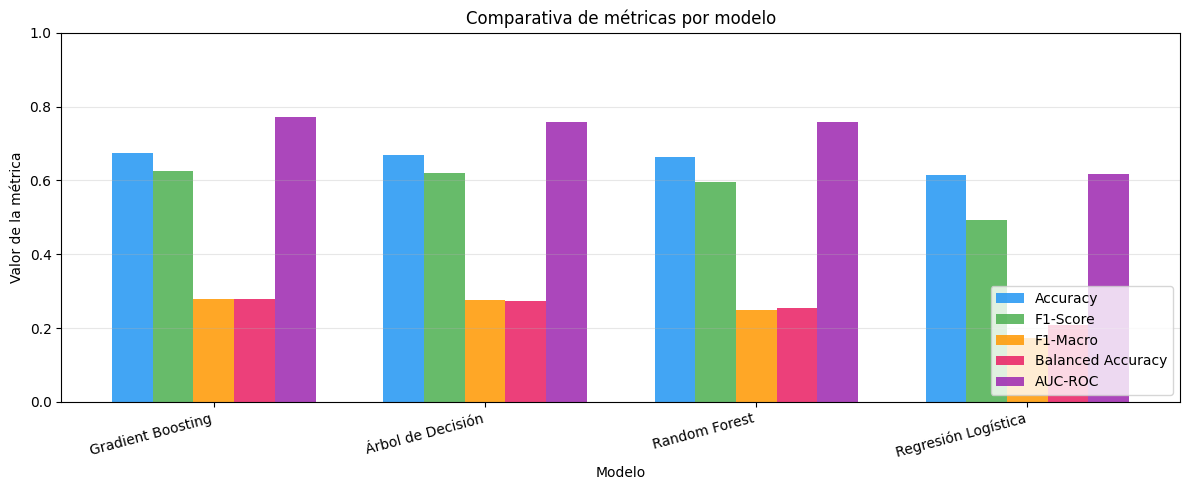

In [ ]:
# Visualización de métricas comparativas
metricas_plot = ['Accuracy', 'F1-Score', 'F1-Macro', 'Balanced Accuracy', 'AUC-ROC']
df_plot = tabla_resultados[metricas_plot]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_plot))
width = 0.15
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

for i, (metrica, color) in enumerate(zip(metricas_plot, colors)):
    ax.bar(x + i*width, df_plot[metrica], width, label=metrica, color=color, alpha=0.85)

ax.set_xlabel('Modelo')
ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparativa de métricas por modelo')
ax.set_xticks(x + width*2)
ax.set_xticklabels(df_plot.index, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3.4 Elección del Mejor Modelo

**Modelo seleccionado: Gradient Boosting**

**Justificación técnica:**
- Obtiene el mayor AUC-ROC (0.7709), indicando mejor capacidad discriminativa entre las 5 clases.
- Mayor F1-Score ponderado (0.6254), equilibrando precisión y recall ante el desbalance de clases.
- Mayor Accuracy (0.6742).

**Justificación de negocio:**
- En el contexto de violencia intrafamiliar, identificar correctamente el tipo de medio utilizado permite focalizar intervenciones preventivas por perfil de víctima y zona geográfica.
- El Gradient Boosting es robusto al desbalance de clases (CONTUNDENTES domina el 61% de los registros), lo que lo hace más confiable para las categorías minoritarias como ARMA DE FUEGO o ESCOPOLAMINA.
- Aunque su tiempo de entrenamiento es mayor, es un costo aceptable para un modelo que se re-entrenaría periódicamente (no en tiempo real).

**Nota:** Random Forest ofrece una alternativa casi igual de buena (AUC 0.7667) con tiempo de entrenamiento 10× menor, siendo la opción recomendada si se necesita velocidad operacional.

# **4. Evaluación del Modelo**

## 4.1 Métricas Detalladas — Mejor Modelo (Gradient Boosting)

Dado que el problema es de **clasificación multiclase**, se reportan:
- **Accuracy**: porcentaje de predicciones correctas globales.
- **Precision / Recall / F1-Score**: calculadas por clase y como promedio ponderado.
- **AUC-ROC**: capacidad de discriminación multiclase (One-vs-Rest, ponderado).


In [ ]:
# Evaluar el mejor modelo en detalle
mejor_modelo_nombre = 'Gradient Boosting'
mejor_modelo = modelos_entrenados[mejor_modelo_nombre]

y_pred_mejor  = mejor_modelo.predict(X_test)
y_proba_mejor = mejor_modelo.predict_proba(X_test)

print(f"=== REPORTE DE CLASIFICACIÓN — {mejor_modelo_nombre} ===\n")
print(classification_report(
    y_test, y_pred_mejor,
    target_names=le.classes_,
    digits=4
))


=== REPORTE DE CLASIFICACIÓN — Gradient Boosting ===

                             precision    recall  f1-score   support

ARMA BLANCA / CORTOPUNZANTE     0.5973    0.0653    0.1177      8133
              ARMA DE FUEGO     0.0000    0.0000    0.0000       465
               CONTUNDENTES     0.6973    0.9048    0.7876     48544
               ESCOPOLAMINA     0.2500    0.0013    0.0026       759
        SIN EMPLEO DE ARMAS     0.5806    0.4170    0.4853     21232

                   accuracy                         0.6736     79133
                  macro avg     0.4250    0.2777    0.2787     79133
               weighted avg     0.6473    0.6736    0.6255     79133



In [ ]:
# Tabla resumen de métricas por clase
report_dict = classification_report(
    y_test, y_pred_mejor,
    target_names=le.classes_,
    output_dict=True
)
df_report = pd.DataFrame(report_dict).T.round(4)
print("Métricas por clase:")
print(df_report[['precision','recall','f1-score','support']].to_string())


Métricas por clase:
                             precision  recall  f1-score     support
ARMA BLANCA / CORTOPUNZANTE     0.5973  0.0653    0.1177   8133.0000
ARMA DE FUEGO                   0.0000  0.0000    0.0000    465.0000
CONTUNDENTES                    0.6973  0.9048    0.7876  48544.0000
ESCOPOLAMINA                    0.2500  0.0013    0.0026    759.0000
SIN EMPLEO DE ARMAS             0.5806  0.4170    0.4853  21232.0000
accuracy                        0.6736  0.6736    0.6736      0.6736
macro avg                       0.4250  0.2777    0.2787  79133.0000
weighted avg                    0.6473  0.6736    0.6255  79133.0000


In [ ]:
# Tabla comparativa final — todas las métricas de todos los modelos
print("=" * 65)
print("     TABLA COMPARATIVA FINAL — TODOS LOS MODELOS")
print("=" * 65)
print(tabla_resultados.to_string())
print("=" * 65)
print(f"\n★ Mejor modelo: {tabla_resultados['F1-Score'].idxmax()}")
print(f"  F1-Score:  {tabla_resultados['F1-Score'].max():.4f}")
print(f"  AUC-ROC:   {tabla_resultados['AUC-ROC'].max():.4f}")
print(f"  Accuracy:  {tabla_resultados['Accuracy'].max():.4f}")


     TABLA COMPARATIVA FINAL — TODOS LOS MODELOS
                     Accuracy  Precision  Recall  F1-Score  F1-Macro  Balanced Accuracy  AUC-ROC  Tiempo (s)
Gradient Boosting      0.6736     0.6473  0.6736    0.6255    0.2787             0.2777   0.7716       280.6
Árbol de Decisión      0.6702     0.6398  0.6702    0.6205    0.2770             0.2747   0.7578         0.9
Random Forest          0.6626     0.6407  0.6626    0.5954    0.2480             0.2548   0.7597        27.6
Regresión Logística    0.6157     0.5198  0.6157    0.4927    0.1723             0.2072   0.6167        10.2

★ Mejor modelo: Gradient Boosting
  F1-Score:  0.6255
  AUC-ROC:   0.7716
  Accuracy:  0.6736


## 4.2 Matriz de Confusión

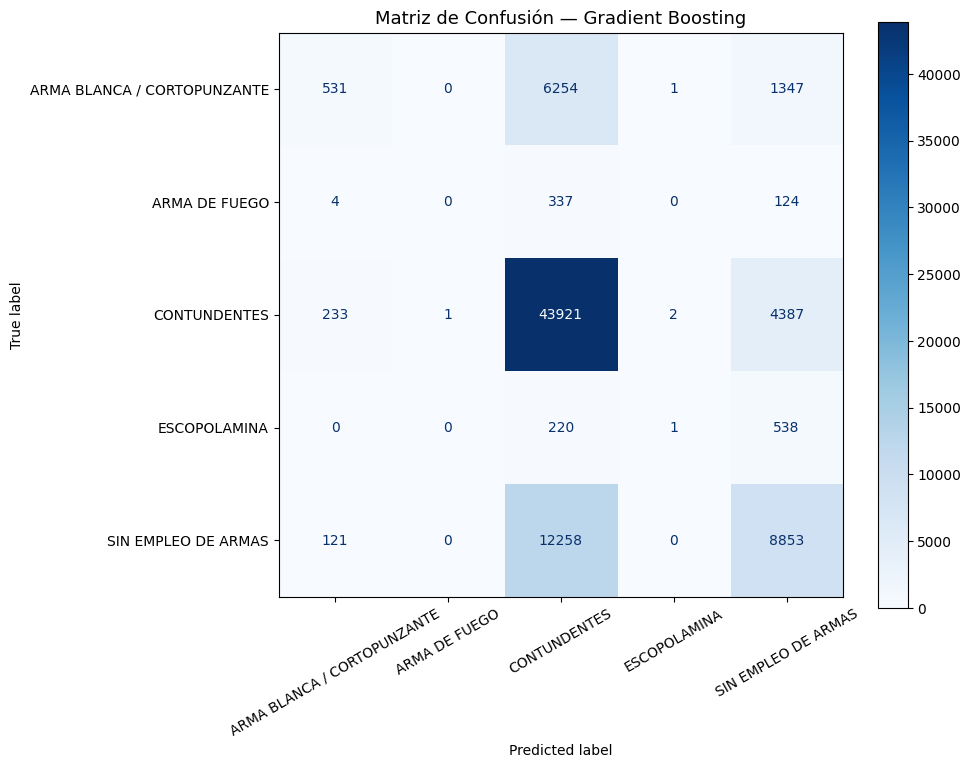

In [ ]:
# Matriz de confusión del mejor modelo
cm = confusion_matrix(y_test, y_pred_mejor)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(
    ax=ax,
    colorbar=True,
    cmap='Blues',
    xticks_rotation=30
)
ax.set_title(f'Matriz de Confusión — {mejor_modelo_nombre}', fontsize=13)
plt.tight_layout()
plt.show()


## 4.3 Curvas ROC por Clase

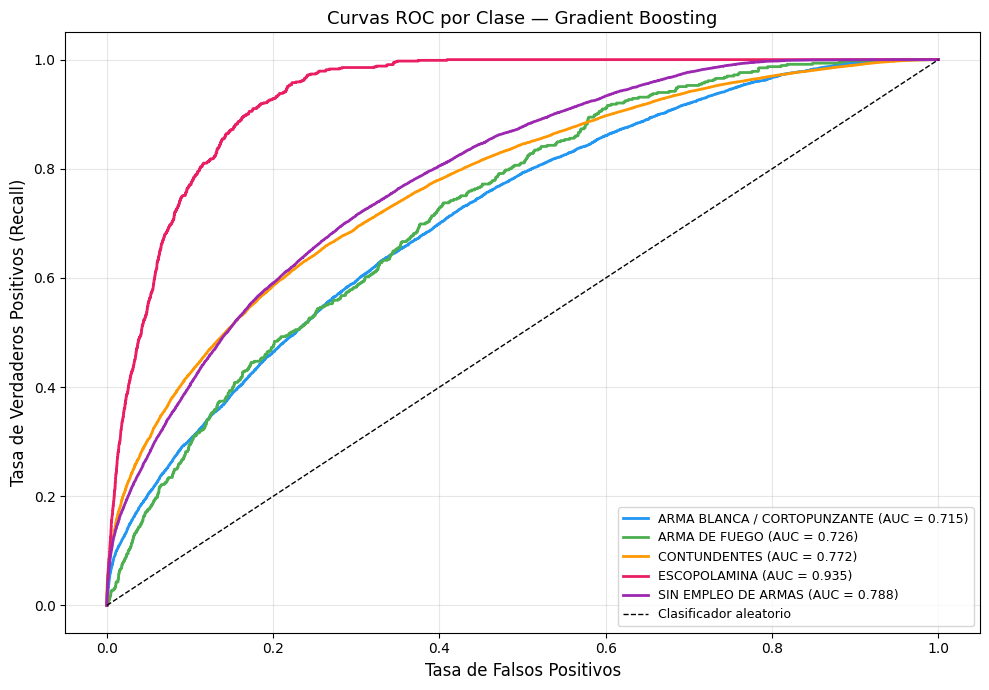

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarizar etiquetas para curvas ROC
y_test_bin = label_binarize(y_test, classes=list(range(len(le.classes_))))

fig, ax = plt.subplots(figsize=(10, 7))
colors_roc = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']

for i, (clase, color) in enumerate(zip(le.classes_, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_mejor[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{clase} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12)
ax.set_title(f'Curvas ROC por Clase — {mejor_modelo_nombre}', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4.4 Importancia de Variables

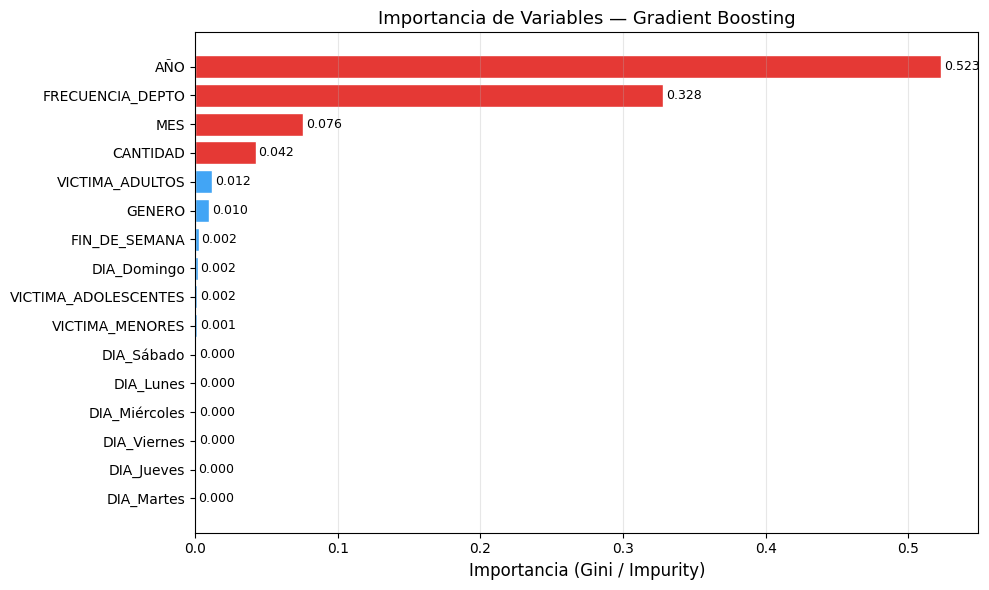


Top 5 variables más importantes:
  AÑO                      : 0.5229 (52.3%)
  FRECUENCIA_DEPTO         : 0.3279 (32.8%)
  MES                      : 0.0757 (7.6%)
  CANTIDAD                 : 0.0424 (4.2%)
  VICTIMA_ADULTOS          : 0.0121 (1.2%)


In [ ]:
# Importancia de variables — Gradient Boosting
importancias = pd.Series(
    mejor_modelo.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ['#E53935' if v >= importancias.quantile(0.75) else '#42A5F5'
               for v in importancias.values]
bars = ax.barh(importancias.index, importancias.values, color=colors_imp, edgecolor='white')

ax.set_xlabel('Importancia (Gini / Impurity)', fontsize=12)
ax.set_title(f'Importancia de Variables — {mejor_modelo_nombre}', fontsize=13)

for bar, val in zip(bars, importancias.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 5 variables más importantes:")
top5 = importancias.sort_values(ascending=False).head(5)
for feat, imp in top5.items():
    print(f"  {feat:25s}: {imp:.4f} ({imp*100:.1f}%)")


## 4.5 Interpretación y Justificación del Modelo Seleccionado

El modelo seleccionado fue **Gradient Boosting**, ya que presenta el mejor desempeño global frente a los otros modelos comparados.

Las variables más importantes son AÑO, FRECUENCIA_DEPTO, MES y CANTIAD. Esto sugiere que el tipo de medio reportado está relacionado con cambios temporales, concentración territorial de casos y magnitud del registro. En términos de negocio, esto puede ayudar a las entidades públicas a identificar patrones por periodo y territorio.

La limitación principal es el desbalance de la variable objetivo. Aunque el modelo tiene un desempeño global aceptable, presenta dificultad para identificar correctamente categorías con baja frecuencia, como ARMA DE FUEGO y ESCOPOLAMINA.


# **5. Interpretación de Resultados y Reporte Ejecutivo**

## 5.1

El proyecto desarrolló un modelo de aprendizaje supervisado para clasificar el tipo de medio utilizado en reportes de violencia intrafamiliar en Colombia. La variable objetivo fue `ARMAS MEDIOS`, y el problema se abordó como una clasificación multiclase. El mejor modelo global fue **Gradient Boosting**, debido a que presentó el mejor equilibrio entre F1 ponderado, Accuracy y AUC-ROC dentro de los modelos evaluados.


## 5.2 Caso de negocio y contexto

La violencia intrafamiliar es un problema relevante para entidades gubernamentales, organismos de seguridad y Áreas de protección social. Un modelo predictivo de este tipo puede ayudar a identificar patrones asociados al medio utilizado en los reportes, permitiendo orientar campañas preventivas, fortalecer rutas de atención y priorizar recursos en departamentos o periodos con mayor concentración de casos.


## Respuesta a la Pregunta inicial

La pregunta inicial era si, a partir de variables demográficas, temporales y territoriales, era posible clasificar el tipo de medio reportado en los hechos de violencia intrafamiliar en Colombia.

La respuesta es sí. El modelo Gradient Boosting alcanzó una exactitud del 67% y un AUC-ROC de 0.77 en datos que nunca había visto, lo que indica que efectivamente existen patrones en los datos que permiten anticipar el tipo de medio reportado. No es una predicción perfecta, pero sí es mejor que una clasificación aleatoria, lo cual confirma que las variables disponibles contienen información útil.

Las variables con mayor peso no fueron las demográficas del perfil de la víctima, sino las territoriales y temporales: la frecuencia histórica de reportes por departamento, el año y el mes del hecho.

Sin embargo, el modelo no clasifica igual de bien todas las categorías. Tiene buen desempeño en los medios más frecuentes — CONTUNDENTES y SIN EMPLEO DE ARMAS — pero pierde precisión en categorías como ARMA DE FUEGO y ESCOPOLAMINA, que son menos comunes en el dataset. Esto no invalida el resultado general, pero sí establece un límite claro sobre para qué puede y no puede usarse el modelo.

## 5.3 Metodología y modelos probados

El proceso incluyó limpieza de datos, tratamiento de valores faltantes, depuración de categorías de la variable objetivo, creación de variables temporales, codificación de variables categóricas, escalamiento de variables numéricas y división en entrenamiento y prueba. Luego se compararon cuatro modelos: Regresión Logística, Árbol de Decisión, Random Forest y Gradient Boosting.

## 5.4 Resultados clave y hallazgos

 Las variables más relevantes fueron AÑO, FRECUENCIA_DEPTO, MES y CANTIDAD, lo que indica que los patrones temporales y territoriales tienen un peso importante en la clasificación del medio reportado.

También se evidenció un desbalance fuerte en ARMAS MEDIOS. Las categorías CONTUNDENTES y SIN EMPLEO DE ARMAS concentran la mayor parte de los registros, mientras que ARMA DE FUEGO y ESCOPOLAMINA aparecen con mucha menor frecuencia. Esto afecta la capacidad del modelo para aprender estas clases minoritarias.

**Departamentos y sectores**

En terminos departamentales, la mayor concentracion de reportes se encuentra en Cundinamarca, Antioquia, Valle, Santander y Boyaca. Estos cinco departamentos representan aproximadamente el 64% del total registrado, lo que evidencia una fuerte concentracion territorial.

Tambien hay diferencias importantes por departamento en el tipo de medio reportado. En Boyaca, Valle, Santander, Atlantico y Meta predominan los casos clasificados como CONTUNDENTES, mientras que en Cundinamarca aparece una proporcion muy alta de NO REPORTADO, lo cual sugiere posibles diferencias en calidad del registro. Bolivar muestra una participacion relativamente mas alta de ARMA BLANCA / CORTOPUNZANTE frente a otros departamentos.

Por sectores poblacionales, los registros se concentran principalmente en mujeres y adultos. Esto es congruente con el contexto del problema, ya que la violencia intrafamiliar suele afectar de manera desproporcionada a mujeres adultas dentro del entorno domestico.

## 5.5 Limitaciones del estudio

El modelo tiene buen desempeño general, pero bajo desempeño en algunas clases minoritarias. Por esta razón, no debe interpretarse como una solución definitiva para decisiones individuales o judiciales. Además, la variable FRECUENCIA_DEPTO debe revisarse en futuras versiones para evitar posibles sesgos territoriales.

Otra limitación es que el dataset corresponde a casos reportados, no necesariamente a la totalidad de casos ocurridos. Por lo tanto, los resultados reflejan patrones de denuncia y registro, no toda la realidad de la violencia intrafamiliar en Colombia.

## 5.6 Recomendaciones para la toma de decisiones

A partir de los resultados, se recomienda usar el modelo como una herramienta de apoyo para la planeacion preventiva. Su mayor valor esta en identificar territorios, periodos y perfiles donde se concentran ciertos tipos de medios reportados, permitiendo que las entidades prioricen recursos, fortalezcan rutas de atencion y diseñen acciones diferenciadas segun el comportamiento de cada departamento.

## 5.7 Insights accionables
1. Concentración territorial: asignar recursos donde los patrones lo indican

La frecuencia histórica de reportes por departamento fue una de las variables más importantes del modelo, lo que indica que departamentos como Antioquia, Cundinamarca y Valle no solo concentran más casos sino que también presentan dinámicas distintas. Entidades como la Policía Nacional deberían adoptar una estrategia de priorización territorial diferenciada en lugar de distribuir recursos de forma uniforme en todo el país.

2. Estacionalidad: anticiparse al pico, no reaccionar después

Las variables MES y AÑO tuvieron peso relevante en el modelo. Los primeros meses del año concentran más reportes, lo que abre una ventana concreta para programar campañas preventivas entre noviembre y enero, antes del pico, y planear con anticipación la disponibilidad de equipos de atención y casas de acogida.

3. Perfil de la víctima: segmentar la respuesta, no estandarizarla

Los registros se concentran en mujeres adultas, pero el modelo también detecta casos en menores y adolescentes con tipos de medio distintos. La ruta de atención, el perfil del profesional asignado y el seguimiento requerido deberían variar según el grupo, no aplicar la misma respuesta para todos los casos.

4. Clases minoritarias: el modelo falla donde más importa

Las categorías que el modelo predice peor — ARMA DE FUEGO y ESCOPOLAMINA — son precisamente las de mayor gravedad potencial. Por esto, el modelo no debe usarse como criterio único de decisión sino como un insumo que complemente el juicio del funcionario, especialmente en casos donde haya señales de riesgo alto.
